In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")



installing al libary's 

In [2]:
print("hell")
df = pd.read_csv("insurance.csv")

hell


In [3]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# eda

In [4]:
df.shape

(1338, 7)

In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

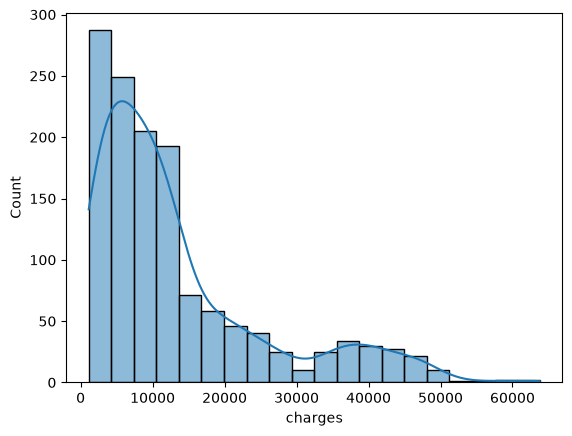

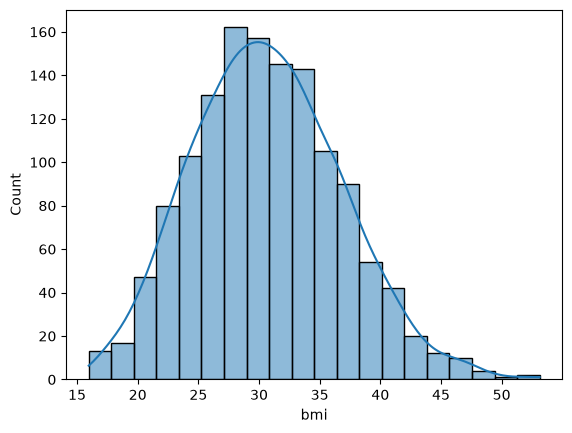

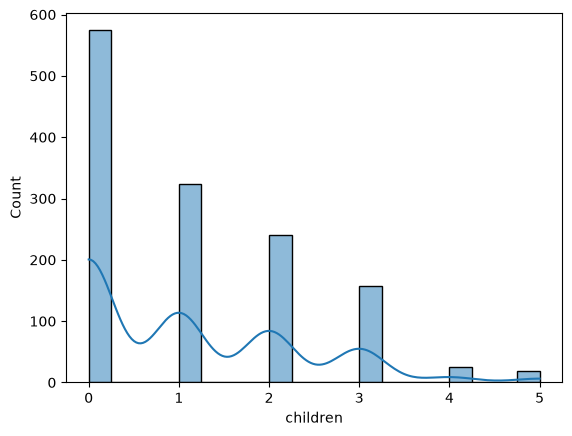

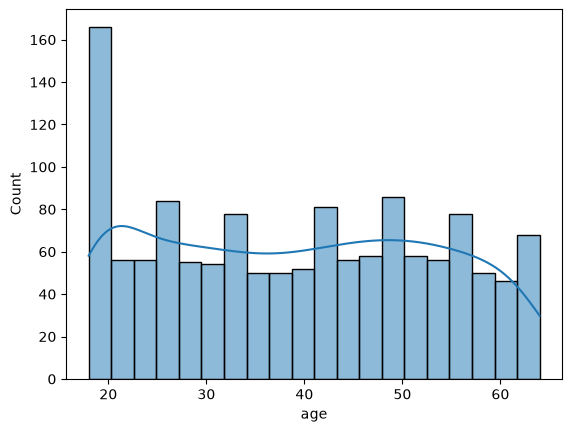

In [9]:
numeric_colunm=['charges', 'bmi', 'children',   'age']
for col in numeric_colunm:
    plt.Figure(figsize=(6,4))
    sns.histplot(df[col], kde= True, bins=20)
    plt.show()

<Axes: xlabel='children', ylabel='count'>

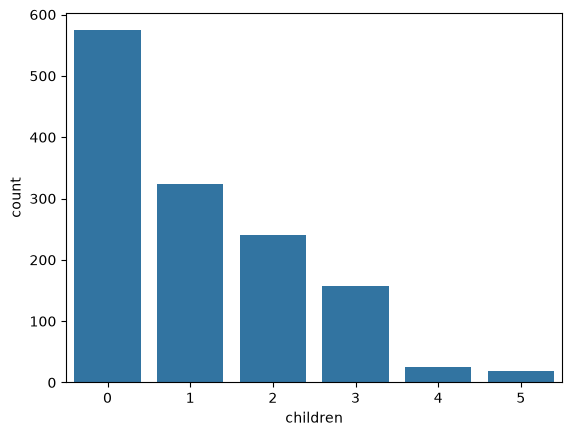

In [10]:
sns.countplot(x=df["children"])


<Axes: xlabel='sex', ylabel='count'>

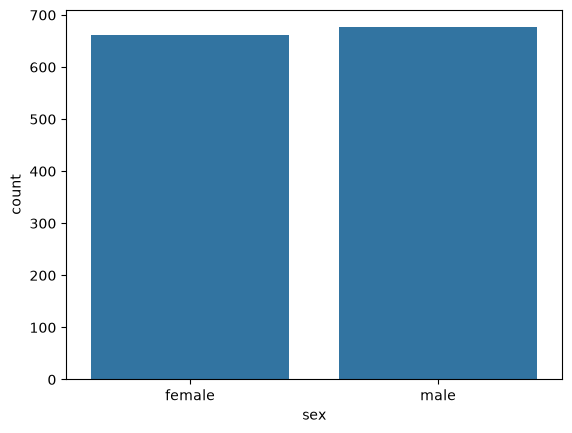

In [11]:
sns.countplot(x=df["sex"])

<Axes: xlabel='smoker', ylabel='count'>

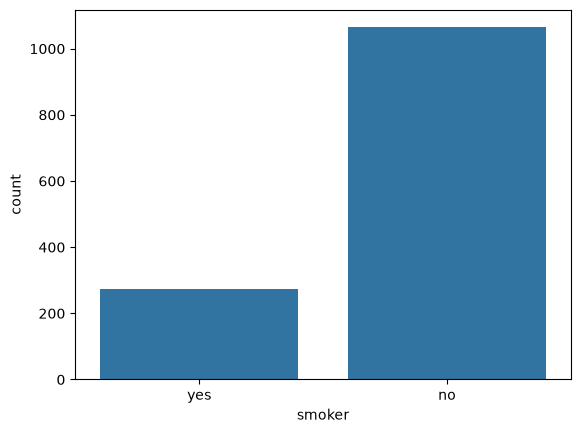

In [12]:
sns.countplot(x=df["smoker"])

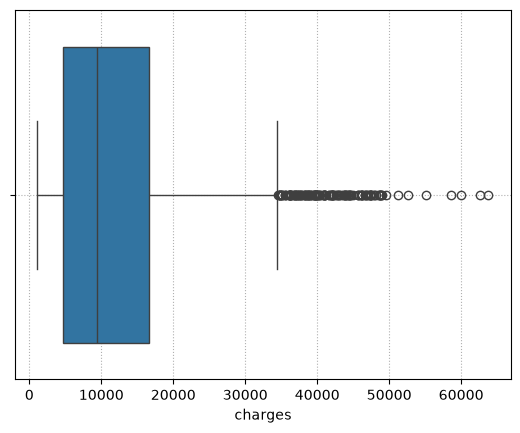

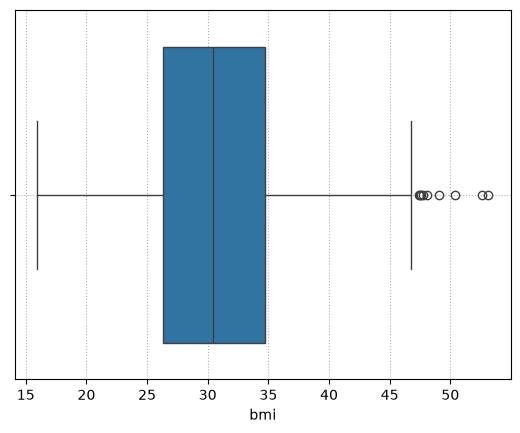

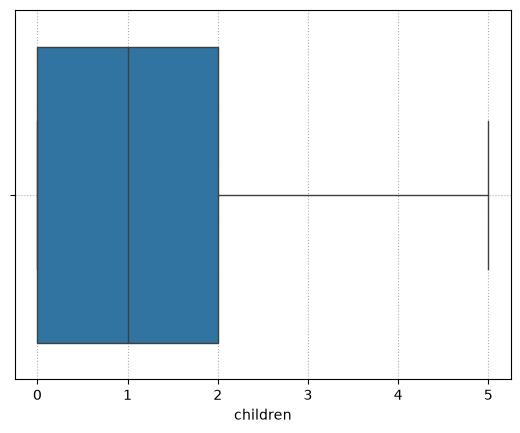

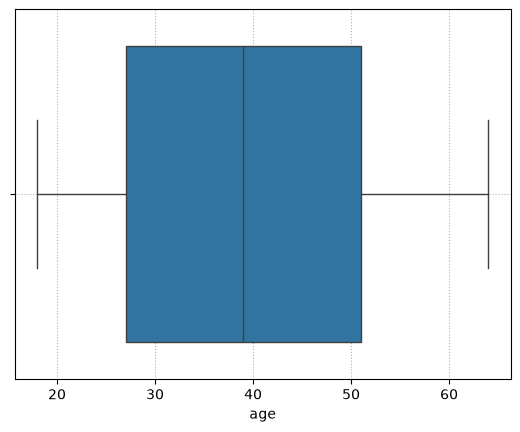

In [13]:
for col in numeric_colunm:
    plt.Figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.grid(True, linestyle=":")
    plt.show()

<Axes: >

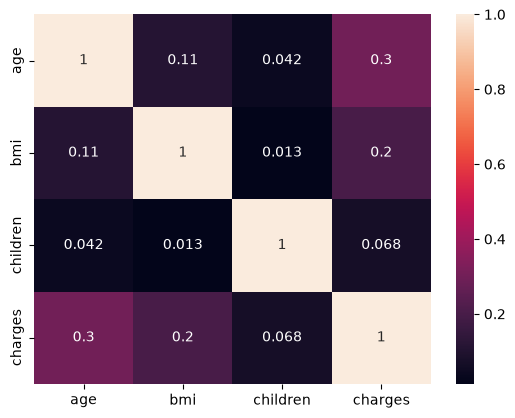

In [14]:
plt.Figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)

# data cleaning and procesing

In [15]:
data_clean =  df.copy()

In [16]:
data_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [17]:
data_clean.insert(5, "ext_smk", np.where(data_clean["smoker"]== "yes" , data_clean["charges"]*0.10 , 0))

In [18]:
data_clean.drop_duplicates(inplace=True)
data_clean.head()


,age,sex,bmi,children,smoker,ext_smk,region,charges
0,19,female,27.900,0,yes,1688.4924,southwest,16884.92400
1,18,male,33.770,1,no,0.0000,southeast,1725.55230
2,28,male,33.000,3,no,0.0000,southeast,4449.46200
3,33,male,22.705,0,no,0.0000,northwest,21984.47061
4,32,male,28.880,0,no,0.0000,northwest,3866.85520


In [19]:
data_clean.shape

(1337, 8)

In [20]:
data_clean.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
ext_smk     0
region      0
charges     0
dtype: int64

In [21]:
data_clean["sex"].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [22]:
data_clean["sex"].value_counts().sum()

np.int64(1337)

In [23]:
data_clean["sex"] = data_clean["sex"].map({"male":1, "female":0})

In [24]:
data_clean.head()

,age,sex,bmi,children,smoker,ext_smk,region,charges
0,19,0,27.900,0,yes,1688.4924,southwest,16884.92400
1,18,1,33.770,1,no,0.0000,southeast,1725.55230
2,28,1,33.000,3,no,0.0000,southeast,4449.46200
3,33,1,22.705,0,no,0.0000,northwest,21984.47061
4,32,1,28.880,0,no,0.0000,northwest,3866.85520


In [25]:
data_clean["smoker"]= data_clean["smoker"].map({"no":0, "yes":1})
data_clean.head()

,age,sex,bmi,children,smoker,ext_smk,region,charges
0,19,0,27.900,0,1,1688.4924,southwest,16884.92400
1,18,1,33.770,1,0,0.0000,southeast,1725.55230
2,28,1,33.000,3,0,0.0000,southeast,4449.46200
3,33,1,22.705,0,0,0.0000,northwest,21984.47061
4,32,1,28.880,0,0,0.0000,northwest,3866.85520


In [26]:
data_clean.rename(columns={
    "sex":"ismale",
    "smoker":"is smoker"
},  inplace=True)

data_clean.head()

,age,ismale,bmi,children,is smoker,ext_smk,region,charges
0,19,0,27.900,0,1,1688.4924,southwest,16884.92400
1,18,1,33.770,1,0,0.0000,southeast,1725.55230
2,28,1,33.000,3,0,0.0000,southeast,4449.46200
3,33,1,22.705,0,0,0.0000,northwest,21984.47061
4,32,1,28.880,0,0,0.0000,northwest,3866.85520


In [27]:
data_clean= pd.get_dummies(data_clean, columns=["region"])

In [28]:
data_clean.head()

,age,ismale,bmi,children,is smoker,ext_smk,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,1688.4924,16884.92400,False,False,False,True
1,18,1,33.770,1,0,0.0000,1725.55230,False,False,True,False
2,28,1,33.000,3,0,0.0000,4449.46200,False,False,True,False
3,33,1,22.705,0,0,0.0000,21984.47061,False,True,False,False
4,32,1,28.880,0,0,0.0000,3866.85520,False,True,False,False


In [29]:
data_clean["region_northeast"].dtype

dtype('bool')

In [30]:
data_clean= data_clean.astype(int)

data_clean.head()

,age,ismale,bmi,children,is smoker,ext_smk,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27,0,1,1688,16884,0,0,0,1
1,18,1,33,1,0,0,1725,0,0,1,0
2,28,1,33,3,0,0,4449,0,0,1,0
3,33,1,22,0,0,0,21984,0,1,0,0
4,32,1,28,0,0,0,3866,0,1,0,0


In [31]:
# feature eng... and extraction

<Axes: xlabel='bmi', ylabel='Count'>

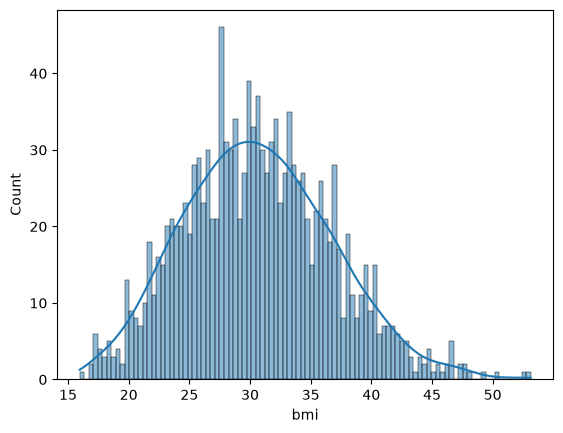

In [32]:
sns.histplot(df["bmi"], kde=True,bins=100)


In [33]:
data_clean["bmi_desribution"]= pd.cut(
    data_clean["bmi"],
    bins=[0,18.5,24,29.5,float('inf')],
    labels=['underweight', 'normal', 'overwait', 'obess']
)

In [34]:
data_clean= pd.get_dummies(data_clean, columns=["bmi_desribution"])
data_clean.head()

,age,ismale,bmi,children,is smoker,ext_smk,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_desribution_underweight,bmi_desribution_normal,bmi_desribution_overwait,bmi_desribution_obess
0,19,0,27,0,1,1688,16884,0,0,0,1,False,False,True,False
1,18,1,33,1,0,0,1725,0,0,1,0,False,False,False,True
2,28,1,33,3,0,0,4449,0,0,1,0,False,False,False,True
3,33,1,22,0,0,0,21984,0,1,0,0,False,True,False,False
4,32,1,28,0,0,0,3866,0,1,0,0,False,False,True,False


In [35]:
data_clean=data_clean.astype(int)

# feature scaling

In [36]:
data_clean.columns

Index(['age', 'ismale', 'bmi', 'children', 'is smoker', 'ext_smk', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_desribution_underweight',
       'bmi_desribution_normal', 'bmi_desribution_overwait',
       'bmi_desribution_obess'],
      dtype='str')

In [37]:
data_clean.dtypes

age                            int64
ismale                         int64
bmi                            int64
children                       int64
is smoker                      int64
ext_smk                        int64
charges                        int64
region_northeast               int64
region_northwest               int64
region_southeast               int64
region_southwest               int64
bmi_desribution_underweight    int64
bmi_desribution_normal         int64
bmi_desribution_overwait       int64
bmi_desribution_obess          int64
dtype: object

In [38]:
from sklearn.preprocessing import StandardScaler

cols = ['age', 'bmi', 'children']

scaler = StandardScaler()

data_clean[cols] = scaler.fit_transform(data_clean[cols])

data_clean.head()

,age,ismale,bmi,children,is smoker,ext_smk,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_desribution_underweight,bmi_desribution_normal,bmi_desribution_overwait,bmi_desribution_obess
0,-1.440418,0,-0.517949,-0.909234,1,1688,16884,0,0,0,1,0,0,1,0
1,-1.511647,1,0.462463,-0.079442,0,0,1725,0,0,1,0,0,0,0,1
2,-0.799350,1,0.462463,1.580143,0,0,4449,0,0,1,0,0,0,0,1
3,-0.443201,1,-1.334960,-0.909234,0,0,21984,0,1,0,0,0,1,0,0
4,-0.514431,1,-0.354547,-0.909234,0,0,3866,0,1,0,0,0,0,1,0
